# Ejercicio 12: Multimodal Embeddings

## Objetivo de la práctica

El objetivo de este ejercicio es observar cómo modelos multimodales como CLIP llevan texto e imágenes al mismo espacio vectorial, y verificar graficando embeddings en 2D.

### Pasos:

1. Obtener embeddings de imágenes y textos con CLIP.
2. Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).
3. Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.
4. Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).

## Parte 0: Preparación del entorno

Para este ejercicio usamos **CLIP** (*Contrastive Language–Image Pre-training*) de OpenAI, en su
variante `openai/clip-vit-base-patch32`, disponible desde este
[link](https://huggingface.co/openai/clip-vit-base-patch32).

Librerías que necesitamos:

- `transformers` + `torch`: para cargar el modelo CLIP y generar los embeddings.
- `Pillow`: para abrir las imágenes.
- `scikit-learn`: para las proyecciones a 2D (PCA y t-SNE).
- `matplotlib`: para graficar.

### Actividad

1. Instalar e importar las dependencias.

In [1]:
%pip install -q transformers torch pillow scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Importamos 
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from transformers import CLIPModel, CLIPProcessor
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Fijamos la semilla para que las proyecciones (t-SNE)
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

print("torch:", torch.__version__)

c:\Users\david\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.7.1+cpu


## Parte 1: Corpus de imágenes y textos

El corpus está formado por 12 imágenes de Wikimedia Commons guardadas en la carpeta `images/`.

Las 12 imágenes pertenecen a 4 categorías semánticas (3 imágenes cada una). Esas categorías no se
le pasan al modelo: sólo las usamos después para colorear la gráfica y comprobar si CLIP las agrupa solo.

| Categoría | Imágenes |
|---|---|
| animal | gato, perro, elefante |
| comida | pizza, hamburguesa, sushi |
| transporte | avión, bicicleta, tren |
| lugar | torre Eiffel, montaña, playa |

A cada imagen le asociamos una descripción en inglés. Estas 12
descripciones son el *ground truth*: la descripción `i` es la pareja correcta de la imagen `i`, y eso
nos permitirá medir después si el emparejamiento que hace CLIP es el correcto.

### Actividad

1. Listar las imágenes de la carpeta `images/`.
2. Asociar a cada imagen su descripción y su categoría.

In [ ]:
CORPUS = {
    "Airplane":    ("avion",       "a photo of an airplane flying in the sky", "transporte"),
    "Bicicleta":   ("bicicleta",   "a photo of a bicycle",                     "transporte"),
    "Cat":         ("gato",        "a photo of a cat",                         "animal"),
    "Elephant":    ("elefante",    "a photo of an elephant in the savanna",    "animal"),
    "Golde":       ("perro",       "a photo of a golden retriever puppy",      "animal"),
    "Hamburger":   ("hamburguesa", "a photo of a hamburger",                   "comida"),
    "Matterhorn":  ("montana",     "a photo of a snowy mountain peak",         "lugar"),
    "Pizza":       ("pizza",       "a photo of a pizza",                       "comida"),
    "Praia":       ("playa",       "a photo of a beach with the sea",          "lugar"),
    "Steam":       ("tren",        "a photo of a steam locomotive train",      "transporte"),
    "Sushi":       ("sushi",       "a photo of a sushi platter",               "comida"),
    "Tour_Eiffel": ("torre",       "a photo of the Eiffel Tower in Paris",     "lugar"),
}

# Leemos los archivos reales de la carpeta y los ordenamos para tener un orden fijo.
IMG_DIR = Path("images")
paths = sorted(IMG_DIR.glob("*.jpg"))

# Alineamos las tres listas (rutas, descripciones, categorias) usando la palabra clave del nombre.
labels, captions, groups = [], [], []
for p in paths:
    clave = next(k for k in CORPUS if p.name.startswith(k))
    etiqueta, caption, categoria = CORPUS[clave]
    labels.append(etiqueta)
    captions.append(caption)
    groups.append(categoria)

print(f"Se encontraron {len(paths)} imagenes\n")
for i, p in enumerate(paths):
    print(f"[{i:2d}] {labels[i]:12s} | {groups[i]:11s} | {captions[i]}")

Se encontraron 12 imagenes

[ 0] avion        | transporte  | a photo of an airplane flying in the sky
[ 1] bicicleta    | transporte  | a photo of a bicycle
[ 2] gato         | animal      | a photo of a cat
[ 3] elefante     | animal      | a photo of an elephant in the savanna
[ 4] perro        | animal      | a photo of a golden retriever puppy
[ 5] hamburguesa  | comida      | a photo of a hamburger
[ 6] montana      | lugar       | a photo of a snowy mountain peak
[ 7] pizza        | comida      | a photo of a pizza
[ 8] playa        | lugar       | a photo of a beach with the sea
[ 9] tren         | transporte  | a photo of a steam locomotive train
[10] sushi        | comida      | a photo of a sushi platter
[11] torre        | lugar       | a photo of the Eiffel Tower in Paris


Confirmamos que las 12 imágenes se leyeron y que cada una quedó alineada con su descripción y su
categoría. Ahora las mostramos para verificar visualmente que el emparejamiento del código es correcto
(que la imagen del índice 4 sea de verdad un perro, etc.).

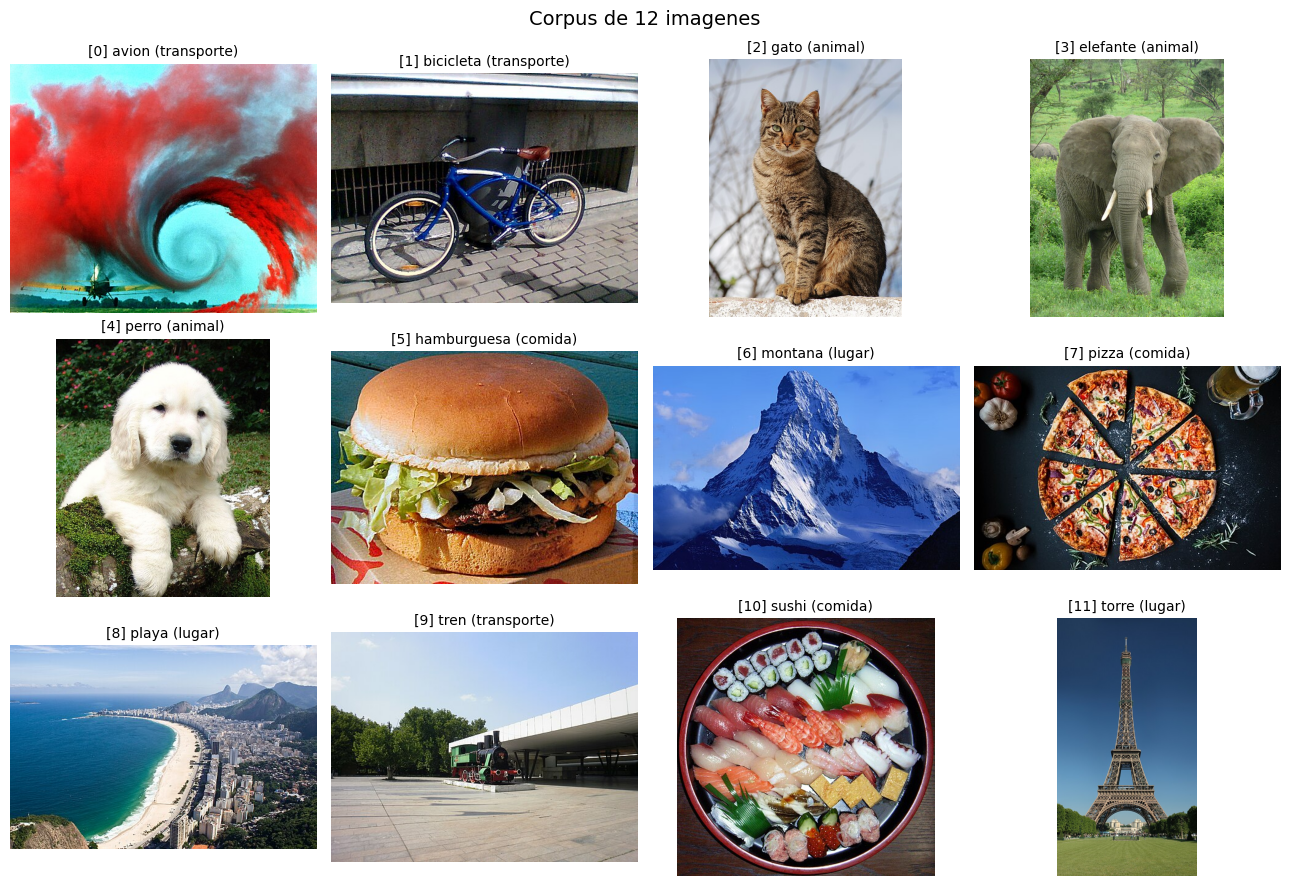

In [3]:
# Abrimos las imagenes con Pillow y las mostramos en una cuadricula de 3x4,
# poniendo como titulo el indice y la etiqueta con la que quedaron asociadas.
images = [Image.open(p).convert("RGB") for p in paths]

fig, axes = plt.subplots(3, 4, figsize=(13, 9))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    ax.set_title(f"[{i}] {labels[i]} ({groups[i]})", fontsize=10)
    ax.axis("off")
plt.suptitle("Corpus de 12 imagenes", fontsize=14)
plt.tight_layout()
plt.show()

## Parte 2: Carga del modelo CLIP

CLIP tiene **dos codificadores**:

- un *image encoder* (aquí un Vision Transformer, ViT-B/32),
- un *text encoder* (un Transformer de texto).

Cada encoder produce un vector, y al final una capa de proyección lleva ambos vectores a un espacio
común de la misma dimensión (`projection_dim`).

In [4]:
# El "processor" hace el preprocesamiento: redimensiona/normaliza imagenes y tokeniza texto.
MODEL_ID = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(MODEL_ID)
processor = CLIPProcessor.from_pretrained(MODEL_ID)
model.eval()  # modo inferencia: no vamos a entrenar, solo a extraer embeddings

# Revisamos las dimensiones internas para entender la arquitectura de las dos torres.
print("Dimension interna del encoder de IMAGEN (ViT):", model.config.vision_config.hidden_size)
print("Dimension interna del encoder de TEXTO       :", model.config.text_config.hidden_size)
print("Dimension del espacio COMUN (projection_dim) :", model.config.projection_dim)
print("Parametros totales:", f"{model.num_parameters():,}")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 59324.53it/s]


Dimension interna del encoder de IMAGEN (ViT): 768
Dimension interna del encoder de TEXTO       : 512
Dimension del espacio COMUN (projection_dim) : 512
Parametros totales: 151,277,313


Aquí ya se ve la idea central: las torres trabajan internamente con dimensiones distintas (768 la de
imagen, 512 la de texto), pero ambas proyectan a un espacio común de 512 dimensiones.

## Parte 3: Embeddings de imágenes y de textos

Ahora generamos los vectores. Dos detalles importantes:

- `get_image_features` / `get_text_features` devuelven el vector ya proyectado al espacio común,
  lo tomamos de `.pooler_output`.
- Normalizamos los vectores a norma 1 (vector unitario). Así el producto punto entre dos vectores es
  directamente su similitud coseno.

In [6]:
# torch.no_grad(): no necesitamos gradientes porque solo hacemos inferencia (ahorra memoria).
with torch.no_grad():
    # --- Torre de imagen ---
    entradas_img = processor(images=images, return_tensors="pt")
    emb_img = model.get_image_features(**entradas_img).pooler_output

    # --- Torre de texto --- (padding=True para que todos los captions tengan el mismo largo)
    entradas_txt = processor(text=captions, return_tensors="pt", padding=True)
    emb_txt = model.get_text_features(**entradas_txt).pooler_output

print("Embeddings de IMAGEN:", tuple(emb_img.shape), "->", emb_img.shape[0], "imagenes x", emb_img.shape[1], "dimensiones")
print("Embeddings de TEXTO :", tuple(emb_txt.shape), "->", emb_txt.shape[0], "textos   x", emb_txt.shape[1], "dimensiones")

Embeddings de IMAGEN: (12, 512) -> 12 imagenes x 512 dimensiones
Embeddings de TEXTO : (12, 512) -> 12 textos   x 512 dimensiones


In [7]:
# Normalizamos a norma 1. producto punto == similitud coseno.
img_n = torch.nn.functional.normalize(emb_img, p=2, dim=-1).numpy()
txt_n = torch.nn.functional.normalize(emb_txt, p=2, dim=-1).numpy()

print("Norma de los vectores de imagen (primeros 4):", np.round(np.linalg.norm(img_n, axis=1)[:4], 4))
print("Norma de los vectores de texto  (primeros 4):", np.round(np.linalg.norm(txt_n, axis=1)[:4], 4))
print()
print("Ejemplo, primeras 8 dimensiones del vector de la imagen [2] (gato):")
print(np.round(img_n[2][:8], 4))
print("Ejemplo, primeras 8 dimensiones del vector del texto  [2] ('a photo of a cat'):")
print(np.round(txt_n[2][:8], 4))

Norma de los vectores de imagen (primeros 4): [1. 1. 1. 1.]
Norma de los vectores de texto  (primeros 4): [1. 1. 1. 1.]

Ejemplo, primeras 8 dimensiones del vector de la imagen [2] (gato):
[ 0.0018  0.005   0.017  -0.0621 -0.0148 -0.0091  0.0189  0.0156]
Ejemplo, primeras 8 dimensiones del vector del texto  [2] ('a photo of a cat'):
[ 0.0148  0.007  -0.0234 -0.0211 -0.0185  0.0196 -0.0303 -0.0747]


## Parte 4: Matriz de similitud coseno

Si de verdad viven en el mismo espacio, la similitud coseno entre una imagen y su descripción debe
ser mayor que con las descripciones de las otras 11 imágenes. Calculamos la matriz completa de
12 textos x 12 imágenes: la diagonal son los pares correctos.

In [9]:
# S[i, j] = similitud entre el TEXTO i y la IMAGEN j.
S = txt_n @ img_n.T
print("Forma de la matriz de similitud:", S.shape)

# Comparamos el promedio de la diagonal (pares correctos) contra el resto (pares incorrectos).
diagonal = np.diag(S)
fuera = S[~np.eye(12, dtype=bool)]
print(f"\nSimilitud media de los pares CORRECTOS (diagonal): {diagonal.mean():.4f}")
print(f"Similitud media de los pares INCORRECTOS         : {fuera.mean():.4f}")

Forma de la matriz de similitud: (12, 12)

Similitud media de los pares CORRECTOS (diagonal): 0.2908
Similitud media de los pares INCORRECTOS         : 0.1688


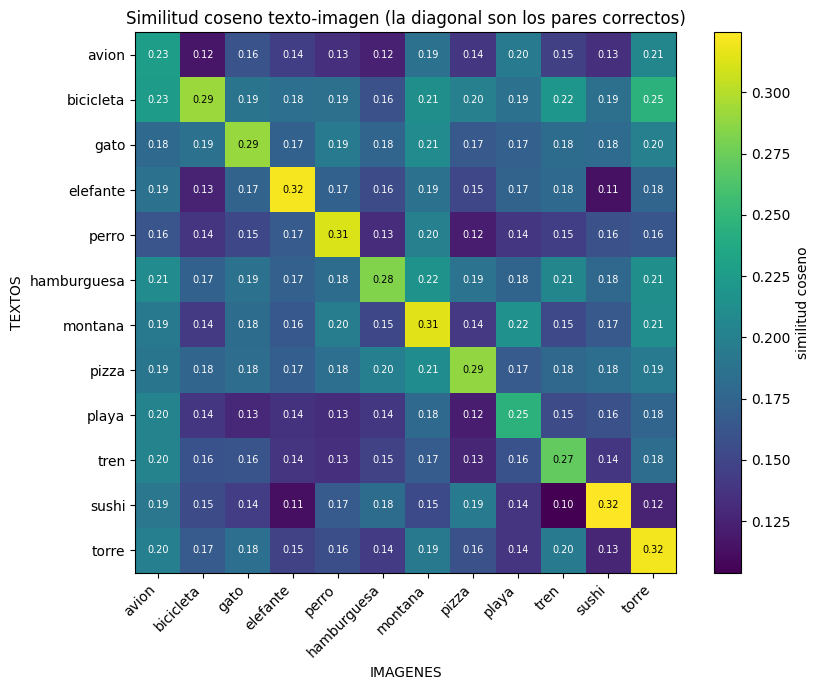

In [10]:
# Heatmap de la matriz
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(S, cmap="viridis")
ax.set_xticks(range(12), labels, rotation=45, ha="right")
ax.set_yticks(range(12), labels)
ax.set_xlabel("IMAGENES"); ax.set_ylabel("TEXTOS")
ax.set_title("Similitud coseno texto-imagen (la diagonal son los pares correctos)")

# Escribimos el valor dentro de cada celda para poder leer los numeros.
for i in range(12):
    for j in range(12):
        ax.text(j, i, f"{S[i, j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if S[i, j] < 0.25 else "black")
plt.colorbar(im, label="similitud coseno")
plt.tight_layout()
plt.show()

## Parte 5: Búsqueda texto→imagen e imagen→texto

La consulta y los documentos son de tipos distintos.
Si el `argmax` de cada fila cae en la diagonal, el emparejamiento fue perfecto.

In [12]:
# TEXTO -> IMAGEN: por cada fila (texto), la imagen con mayor similitud.
pred_t2i = S.argmax(axis=1)
acc_t2i = (pred_t2i == np.arange(12)).mean()

print("BUSQUEDA TEXTO -> IMAGEN")
print("-" * 78)
for i in range(12):
    correcto = "OK" if pred_t2i[i] == i else "XX"
    print(f"{correcto} '{captions[i][:38]:38s}' -> imagen [{pred_t2i[i]:2d}] {labels[pred_t2i[i]]:12s} (cos={S[i, pred_t2i[i]]:.3f})")
print("-" * 78)

BUSQUEDA TEXTO -> IMAGEN
------------------------------------------------------------------------------
OK 'a photo of an airplane flying in the s' -> imagen [ 0] avion        (cos=0.226)
OK 'a photo of a bicycle                  ' -> imagen [ 1] bicicleta    (cos=0.292)
OK 'a photo of a cat                      ' -> imagen [ 2] gato         (cos=0.290)
OK 'a photo of an elephant in the savanna ' -> imagen [ 3] elefante     (cos=0.322)
OK 'a photo of a golden retriever puppy   ' -> imagen [ 4] perro        (cos=0.312)
OK 'a photo of a hamburger                ' -> imagen [ 5] hamburguesa  (cos=0.283)
OK 'a photo of a snowy mountain peak      ' -> imagen [ 6] montana      (cos=0.315)
OK 'a photo of a pizza                    ' -> imagen [ 7] pizza        (cos=0.289)
OK 'a photo of a beach with the sea       ' -> imagen [ 8] playa        (cos=0.245)
OK 'a photo of a steam locomotive train   ' -> imagen [ 9] tren         (cos=0.271)
OK 'a photo of a sushi platter            ' -> imagen [1

In [14]:
# IMAGEN -> TEXTO:
pred_i2t = S.argmax(axis=0)
acc_i2t = (pred_i2t == np.arange(12)).mean()

print("BUSQUEDA IMAGEN -> TEXTO")
print("-" * 78)
for j in range(12):
    correcto = "OK" if pred_i2t[j] == j else "XX"
    print(f"{correcto} imagen [{j:2d}] {labels[j]:12s} -> '{captions[pred_i2t[j]][:38]:38s}' (cos={S[pred_i2t[j], j]:.3f})")
print("-" * 78)

BUSQUEDA IMAGEN -> TEXTO
------------------------------------------------------------------------------
OK imagen [ 0] avion        -> 'a photo of an airplane flying in the s' (cos=0.226)
OK imagen [ 1] bicicleta    -> 'a photo of a bicycle                  ' (cos=0.292)
OK imagen [ 2] gato         -> 'a photo of a cat                      ' (cos=0.290)
OK imagen [ 3] elefante     -> 'a photo of an elephant in the savanna ' (cos=0.322)
OK imagen [ 4] perro        -> 'a photo of a golden retriever puppy   ' (cos=0.312)
OK imagen [ 5] hamburguesa  -> 'a photo of a hamburger                ' (cos=0.283)
OK imagen [ 6] montana      -> 'a photo of a snowy mountain peak      ' (cos=0.315)
OK imagen [ 7] pizza        -> 'a photo of a pizza                    ' (cos=0.289)
OK imagen [ 8] playa        -> 'a photo of a beach with the sea       ' (cos=0.245)
OK imagen [ 9] tren         -> 'a photo of a steam locomotive train   ' (cos=0.271)
OK imagen [10] sushi        -> 'a photo of a sushi platt

In [12]:
# Consultas nuevas, escritas por nosotros y que no estan en el corpus de captions.
consultas = [
    "japanese food",             # deberia traer sushi
    "a big grey animal",         # deberia traer el elefante
    "something to travel fast",  # avion / tren
    "a place to go on vacation", # playa / torre / montana
]

with torch.no_grad():
    q_emb = model.get_text_features(**processor(text=consultas, return_tensors="pt", padding=True)).pooler_output
q_n = torch.nn.functional.normalize(q_emb, p=2, dim=-1).numpy()

# Similitud de cada consulta contra las 12 imagenes, y nos quedamos con el top-3.
S_q = q_n @ img_n.T
for i, consulta in enumerate(consultas):
    top3 = np.argsort(-S_q[i])[:3]  # el "-" es para ordenar de mayor a menor
    print(f"Consulta: '{consulta}'")
    for puesto, j in enumerate(top3, 1):
        print(f"   {puesto}. {labels[j]:12s} (cos={S_q[i, j]:.3f})")
    print()

Consulta: 'japanese food'

   1. sushi        (cos=0.292)
   2. hamburguesa  (cos=0.229)
   3. pizza        (cos=0.204)

Consulta: 'a big grey animal'
   1. elefante     (cos=0.257)
   2. gato         (cos=0.231)
   3. torre        (cos=0.212)

Consulta: 'something to travel fast'
   1. bicicleta    (cos=0.249)
   2. torre        (cos=0.235)
   3. tren         (cos=0.227)

Consulta: 'a place to go on vacation'
   1. torre        (cos=0.249)
   2. playa        (cos=0.239)
   3. montana      (cos=0.228)



## Parte 6: Proyección a 2D (PCA y t-SNE)

Los vectores tienen 512 dimensiones y no se pueden dibujar. Para verlos, los reducimos a 2D.

Usamos dos técnicas para no depender de una sola:

- **PCA**: lineal, conserva las direcciones de mayor varianza (se puede interpretar).
- **t-SNE**: no lineal, prioriza conservar las vecindades locales (se ven mejor los grupos).


In [15]:
# Apilamos: las filas 0-11 son imagenes y las filas 12-23 son textos.
X = np.vstack([img_n, txt_n])
print("Matriz conjunta:", X.shape, "(12 imagenes + 12 textos, 512 dimensiones)")

# PCA: proyeccion lineal a 2 componentes.
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X)
print("\nVarianza explicada por PC1 y PC2:", np.round(pca.explained_variance_ratio_, 4))
print("Varianza total conservada:", f"{pca.explained_variance_ratio_.sum():.2%}")

# t-SNE: perplexity debe ser menor al numero de puntos; con 24 puntos usamos 5.
tsne = TSNE(n_components=2, perplexity=5, init="pca", random_state=SEED)
X_tsne = tsne.fit_transform(X)
print("Proyeccion t-SNE lista:", X_tsne.shape)

Matriz conjunta: (24, 512) (12 imagenes + 12 textos, 512 dimensiones)

Varianza explicada por PC1 y PC2: [0.3925 0.068 ]
Varianza total conservada: 46.05%
Proyeccion t-SNE lista: (24, 2)


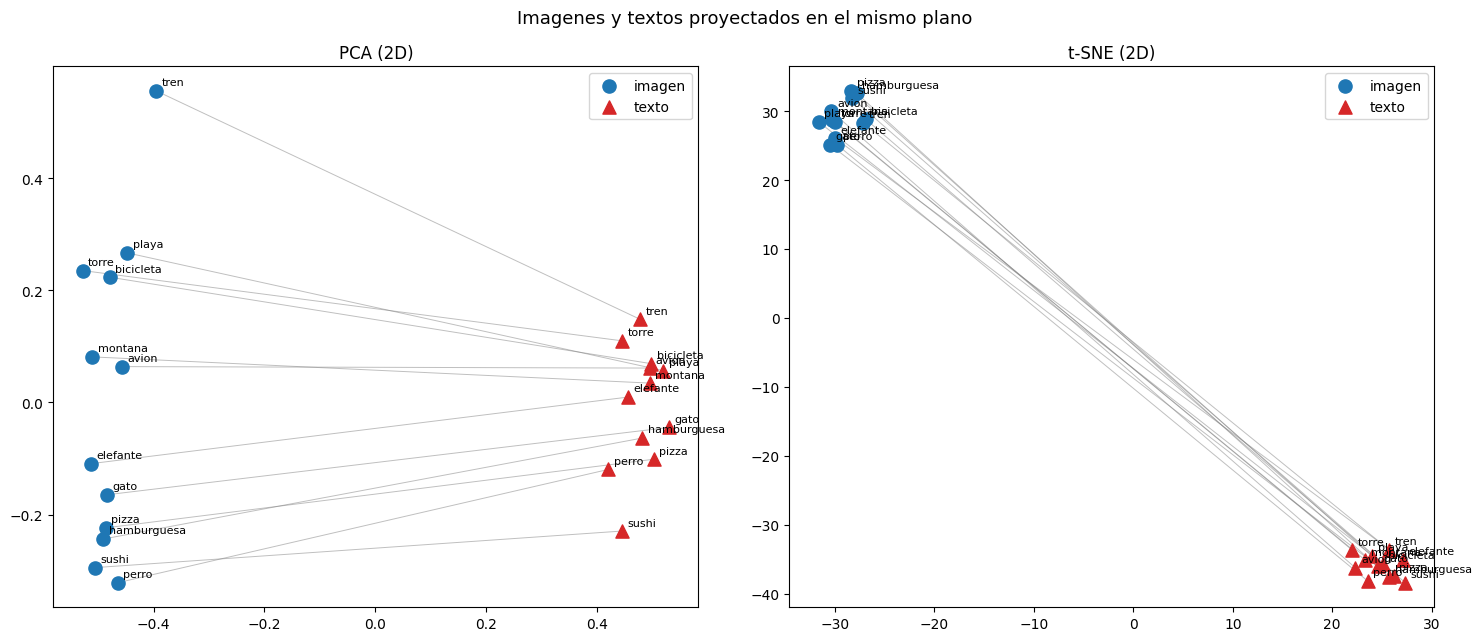

In [ ]:
# dibuja imagenes como circulos y textos como triangulos y une con una linea gris cada imagen con su descripcion correcta.
def graficar(Y, titulo, ax):
    ax.scatter(Y[:12, 0], Y[:12, 1], c="tab:blue", marker="o", s=90, label="imagen", zorder=3)
    ax.scatter(Y[12:, 0], Y[12:, 1], c="tab:red",  marker="^", s=90, label="texto",  zorder=3)
    for i in range(12):
        ax.plot([Y[i, 0], Y[i + 12, 0]], [Y[i, 1], Y[i + 12, 1]], c="gray", lw=0.7, alpha=0.5, zorder=1)
        ax.annotate(labels[i], Y[i],      fontsize=8, xytext=(4, 4), textcoords="offset points")
        ax.annotate(labels[i], Y[i + 12], fontsize=8, xytext=(4, 4), textcoords="offset points")
    ax.set_title(titulo)
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
graficar(X_pca,  "PCA (2D)",    axes[0])
graficar(X_tsne, "t-SNE (2D)",  axes[1])
plt.suptitle("Imagenes y textos proyectados en el mismo plano", fontsize=13)
plt.tight_layout()
plt.show()

## Conclusiones

1. Se generaron con las dos torres del modelo `clip-vit-base-patch32`, obteniendo 12 vectores de imagen y 12 de texto.

2. Las dos matrices resultaron de `(12, 512)`: misma dimensión y,
   por lo tanto, comparables con la misma operación (producto punto = similitud coseno, al estar
   normalizados). Internamente las torres usan dimensiones distintas (768 vs 512), pero la capa de
   proyección las lleva al mismo espacio de 512.

3. Al proyectar las 24 filas juntas con PCA y t-SNE apareció la *brecha de
   modalidad*: imágenes y textos forman dos nubes separadas, porque cada modalidad ocupa su propio cono
   del espacio. Tras centrar cada modalidad por su media, cada imagen quedó junto a su descripción y las
   4 categorías semánticas se agruparon solas, sin que el modelo las conociera.